#### Check Raw Data

In [5]:
# raw 데이터 불러와서 확인
from modules.utils import load_data

# 경로 지정
image_file_path = "./data/raw/panNuke_images.npy"
type_file_path = "./data/raw/panNuke_types.npy"

images, labels, le = load_data(image_file_path, type_file_path)

print("이미지 개수:", len(images))
print("클래스 종류:", le.classes_)
print("숫자 라벨 예시:", labels[:5])
print("숫자 라벨 -> 스트링 라벨", le.inverse_transform([labels[0]])[0])

이미지 개수: 2656
클래스 종류: ['Adrenal_gland' 'Bile-duct' 'Bladder' 'Breast' 'Cervix' 'Colon'
 'Esophagus' 'HeadNeck' 'Kidney' 'Liver' 'Lung' 'Ovarian' 'Pancreatic'
 'Prostate' 'Skin' 'Stomach' 'Testis' 'Thyroid' 'Uterus']
숫자 라벨 예시: [3 3 3 3 3]
숫자 라벨 -> 스트링 라벨 Breast


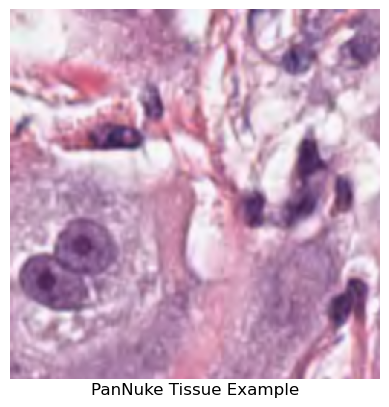

In [6]:
# PanNuke 데이터셋 확인
import matplotlib.pyplot as plt

# 이미지 확인용
first_img = images[0].astype("uint8")

plt.imshow(first_img)
plt.axis("off")

# 아래쪽에 텍스트 추가 (x=중앙, y=조금 아래쪽, ha=center로 정렬)
plt.text(
  x=first_img.shape[1] // 2,    # 가로 중앙
  y=first_img.shape[0] + 10,    # 이미지 아래쪽 위치
  s="PanNuke Tissue Example",
  ha="center",
  fontsize=12
)

plt.show()

-------

#### Tissue classification Using ResNet

In [7]:
# 데이터 전처리 및 저장
from modules.preprocess import generate_processed_dataset

generate_processed_dataset()

Transforming and saving images...


100%|██████████| 2656/2656 [00:02<00:00, 903.07it/s]


✅ 전처리 및 저장 완료.


In [8]:
# 데이터 불러오기
import numpy as np

processed_data_dir = "./data/processed"

images = np.load(f"{processed_data_dir}/resized_images.npy")   # shape: (N, 3, 224, 224)
labels = np.load(f"{processed_data_dir}/labels.npy")           # shape: (N,)
train_idx = np.load(f"{processed_data_dir}/train_indices.npy")
val_idx = np.load(f"{processed_data_dir}/val_indices.npy")

train_imgs = images[train_idx]
val_imgs = images[val_idx]

train_labels = labels[train_idx]
val_labels = labels[val_idx]

print("train 이미지 수:", len(train_imgs))
print("val 이미지 수:", len(val_imgs))
print("train 라벨 수:", len(train_labels))
print("val 라벨 수:", len(val_labels))

train 이미지 수: 2124
val 이미지 수: 532
train 라벨 수: 2124
val 라벨 수: 532


In [9]:
from torchvision import transforms
from torch.utils.data import DataLoader
from modules.custom_datasets import PanNukeDataset

# 이미지 정규화
# ResNet18 등 대부분의 pretrained CNN 모델은 학습 당시 이미지 입력값이 정규화된 상태(예: mean=0.5, std=0.5 혹은 ImageNet 기준 정규화 등)로 들어오는 것을 전제로 하기 때문에, 정규화는 필수 전처리 과정이다.
transform = transforms.Compose([
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3) # [0, 1] → [-1, 1] Normalization
])

# Dataset 구성
train_dataset = PanNukeDataset(train_imgs, train_labels, transform=transform)
val_dataset = PanNukeDataset(val_imgs, val_labels, transform=transform)

print("학습 샘플 수:", len(train_dataset))
print("검증 샘플 수:", len(val_dataset))

# DataLoader 구성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True) # 매 epoch마다 데이터를 랜덤하게 섞어서 학습. -> 모델이 데이터 순서에 과적합되지 않도록 도와줌.
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False) # 검증은 항상 같은 순서로 평가하는 것이 중요해서 섞지 않음.

학습 샘플 수: 2124
검증 샘플 수: 532


In [10]:
import torch
import torch.nn as nn
from modules.models import get_resnet

# 출력층 수정: PanNuke 클래스 수에 맞게 설정
# classes.txt에서 클래스 이름 불러오기
with open("./data/processed/classes.txt") as f:
  class_names = [line.strip() for line in f]

num_classes = len(class_names)
print(f"클래스 수: {num_classes}")

# 모델 생성
resnet_model = get_resnet(num_classes)

# GPU 사용 설정
device = torch.device("mps" if torch.backends.mps.is_available else "cpu")
print(f"MPS 장치가 사용 가능한가? {torch.backends.mps.is_available()}")

resnet = resnet_model.to(device)

# 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss() # multi-class 분류 문제에서 가장 일반적으로 사용된다.
# loss function이 계산한 오차를 바탕으로 모델의 가중치를 업데이트(학습) 해준다.
optimizer = torch.optim.Adam(
  resnet.parameters(), # 모델의 모든 학습가능한 파라미터
  lr=1e-4 # learning rate : 얼마나 빨리 배울 건지
)

클래스 수: 19
MPS 장치가 사용 가능한가? True


In [11]:
from modules.train import train_model
from modules.evaluate import evaluate_model

train_losses = []
val_losses = []

epoch_num = 20
best_val_loss = float("inf")  # 초기값은 무한대

model_path = "./data/results/best_model.pth"

for epoch in range(epoch_num):
    train_loss = train_model(resnet, train_loader, criterion, optimizer, device)
    val_loss = evaluate_model(resnet, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # 현재 모델이 가장 성능 좋으면 저장
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(resnet.state_dict(), model_path)
        print("✅ Best model saved.")
    
    # 가장 최근 모델도 저장
    torch.save(resnet.state_dict(), "./data/results/latest_model.pth")
    print("💾 Latest model saved.")

    print(f"\n📌 Epoch {epoch + 1}, Train Loss {train_loss:.4f}, Val Loss {val_loss:.4f}")

✅ Best model saved.
💾 Latest model saved.

📌 Epoch 1, Train Loss 1.4956, Val Loss 1.0349
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 2, Train Loss 0.6045, Val Loss 0.7177
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 3, Train Loss 0.2112, Val Loss 0.5513
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 4, Train Loss 0.0729, Val Loss 0.5305
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 5, Train Loss 0.0367, Val Loss 0.5104
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 6, Train Loss 0.0252, Val Loss 0.4989
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 7, Train Loss 0.0217, Val Loss 0.4913
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 8, Train Loss 0.0193, Val Loss 0.4686
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 9, Train Loss 0.0111, Val Loss 0.4491
💾 Latest model saved.

📌 Epoch 10, Train Loss 0.0116, Val Loss 0.4874
✅ Best model saved.
💾 Latest model saved.

📌 Epoch 11, Train Loss 0.0072, Val Loss 0.4428
💾 Latest model saved.

📌 Epoch 12, Trai

In [12]:
# 저장된 파일 내용 확인

import torch

state_dict = torch.load("./data/results/best_model.pth")

for k, v in state_dict.items():
  print(f"{k}: {v.shape}")

conv1.weight: torch.Size([64, 3, 7, 7])
bn1.weight: torch.Size([64])
bn1.bias: torch.Size([64])
bn1.running_mean: torch.Size([64])
bn1.running_var: torch.Size([64])
bn1.num_batches_tracked: torch.Size([])
layer1.0.conv1.weight: torch.Size([64, 64, 3, 3])
layer1.0.bn1.weight: torch.Size([64])
layer1.0.bn1.bias: torch.Size([64])
layer1.0.bn1.running_mean: torch.Size([64])
layer1.0.bn1.running_var: torch.Size([64])
layer1.0.bn1.num_batches_tracked: torch.Size([])
layer1.0.conv2.weight: torch.Size([64, 64, 3, 3])
layer1.0.bn2.weight: torch.Size([64])
layer1.0.bn2.bias: torch.Size([64])
layer1.0.bn2.running_mean: torch.Size([64])
layer1.0.bn2.running_var: torch.Size([64])
layer1.0.bn2.num_batches_tracked: torch.Size([])
layer1.1.conv1.weight: torch.Size([64, 64, 3, 3])
layer1.1.bn1.weight: torch.Size([64])
layer1.1.bn1.bias: torch.Size([64])
layer1.1.bn1.running_mean: torch.Size([64])
layer1.1.bn1.running_var: torch.Size([64])
layer1.1.bn1.num_batches_tracked: torch.Size([])
layer1.1.conv2.

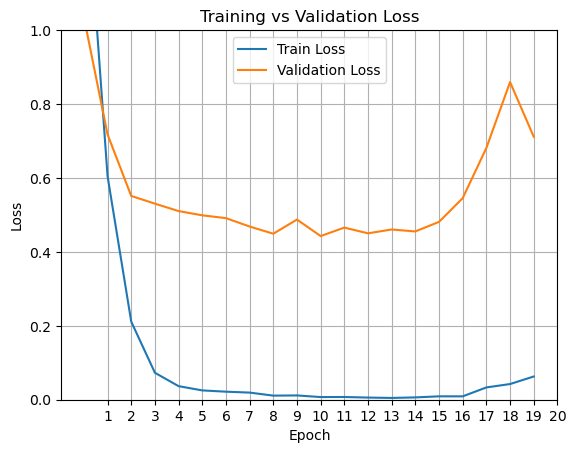

In [13]:
# training/validation loss 시각화하기

import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# y축 범위 지정
plt.ylim(0, 1)

# x축 눈금을 에폭 개수에 맞춰 1 단위로 설정
epochs = list(range(1, len(train_losses) + 1))
plt.xticks(epochs)

plt.show()

Predictions saved to ./data/results/predictions_example.png


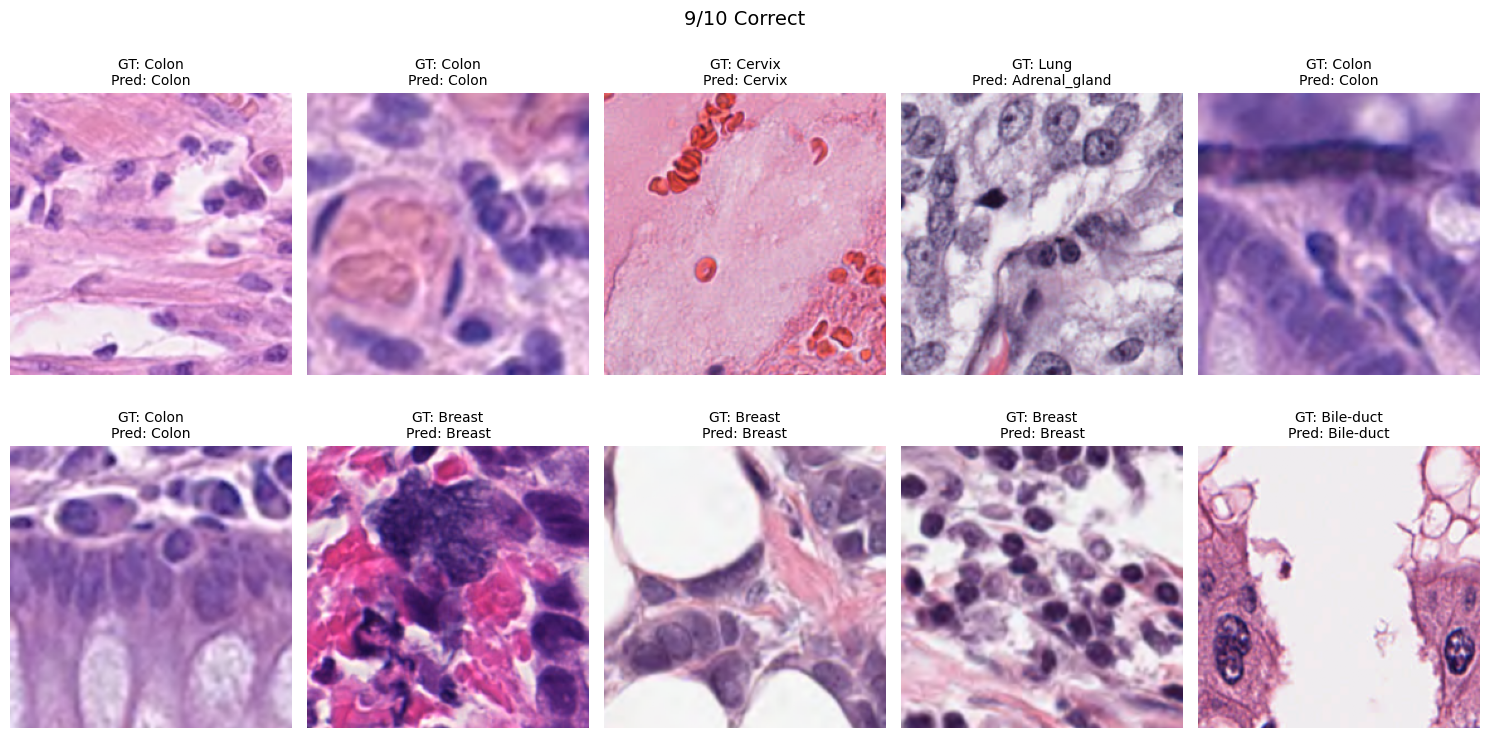

In [14]:
# 저장된 최적의 모델을 불러와 정답 라벨과 비교하며 검증하기

from modules.visualize_prediction import visualize_predictions

# 저장된 best 모델 불러오기
resnet.load_state_dict(torch.load("./data/results/best_model.pth"))
resnet.eval()

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(class_names)

visualize_predictions(
  resnet, 
  val_dataset, 
  le, 
  device, 
  num_samples=10,
  save_path="./data/results/predictions_example.png"
)